In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Script : plot_train_class_distribution.py
But : charger COCO train annotations, compter objets par classe et tracer histogramme + camembert.
Usage exemple :
    python plot_train_class_distribution.py
"""

import os
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import cm
from pycocotools.coco import COCO

# --------- CONFIG ---------
base_path = "/content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Coco_Annotation_vesion"   # <-- ADAPTE ce chemin (dossier qui contient le fichier .coco.json)
ann__train_filename = "_annotations_train.coco.json"  # nom du fichier d'annotations COCO (Train)
ann__valid_filename = "_annotations_valid.coco.json"  # nom du fichier d'annotations COCO (Valid)
ann__test_filename = "_annotations_test.coco.json"  # nom du fichier d'annotations COCO (Test)
output_dir = "/content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/outputs"   # dossier où seront sauvegardés les graphiques
rare_threshold = 30  # classes avec moins de 30 annotations = rares
# --------------------------

# Préparer chemins pour Train File
base_path = Path(base_path)
ann_path = base_path / ann__train_filename
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Vérifications rapides
if not ann_path.exists():
    raise FileNotFoundError(f"Fichier d'annotations introuvable : {ann_path}")


In [2]:
# Charger COCO
coco = COCO(str(ann_path))

# Charger et trier les catégories par id
cats = sorted(coco.loadCats(coco.getCatIds()), key=lambda c: c['id'])
cat_id_to_name = {c['id']: c['name'] for c in cats}
names = [c['name'] for c in cats]

# Charger les annotations (objets)
ann_ids = coco.getAnnIds()
anns = coco.loadAnns(ann_ids)

# Compter les objets par classe (utiliser les noms)
class_counts = Counter()
for ann in anns:
    cat_id = ann['category_id']
    class_name = cat_id_to_name.get(cat_id, str(cat_id))
    class_counts[class_name] += 1

# Trier les classes par fréquence décroissante pour l'affichage
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
sorted_names = [name for name, _ in sorted_counts]
sorted_values = [count for _, count in sorted_counts]

# === Créer DataFrame pandas ===
df_train = pd.DataFrame({
    'class_name': sorted_names,
    'annotations_count': sorted_values
})
df_train['rare'] = df_train['annotations_count'] < rare_threshold


loading annotations into memory...
Done (t=0.66s)
creating index...
index created!


In [3]:
df_train

,class_name,annotations_count,rare
0,Cigarette,1286,False
1,Unlabeled litter,944,False
2,Plastic film,914,False
3,Clear plastic bottle,606,False
4,Other plastic,599,False
5,Other plastic wrapper,546,False
6,Drink can,459,False
7,Plastic bottle cap,416,False
8,Plastic straw,308,False
9,Styrofoam piece,275,False


/tmp/ipython-input-2310424332.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20' if n <= 20 else 'tab20b')


Histogramme sauvegardé : /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/outputs/train_bar_chart.png


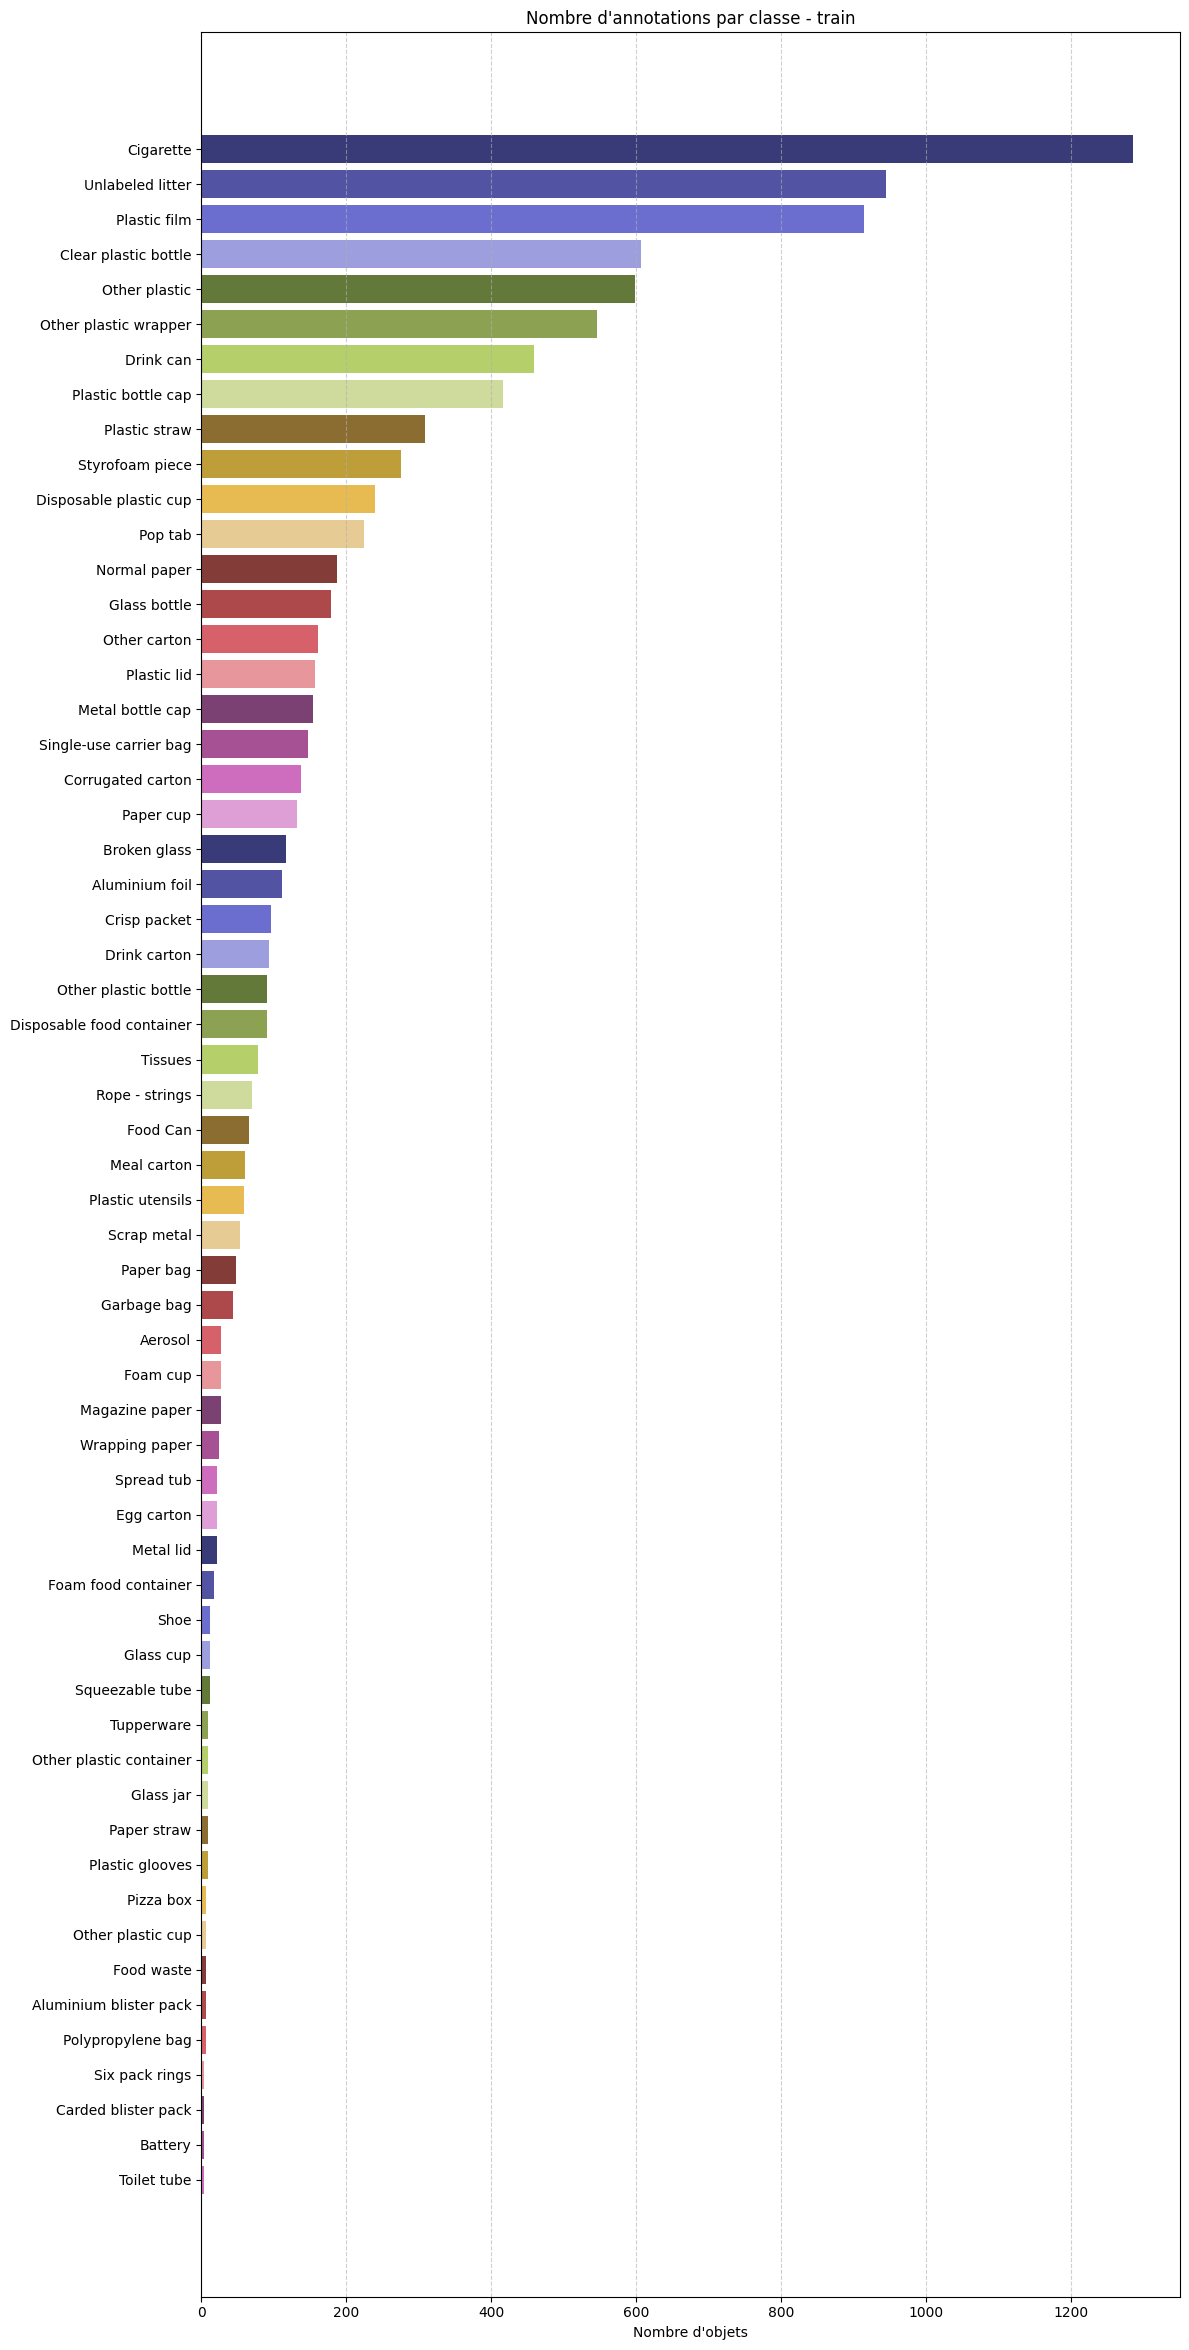

/tmp/ipython-input-2310424332.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('tab20')


Camembert sauvegardé : /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/outputs/train_pie_chart.png


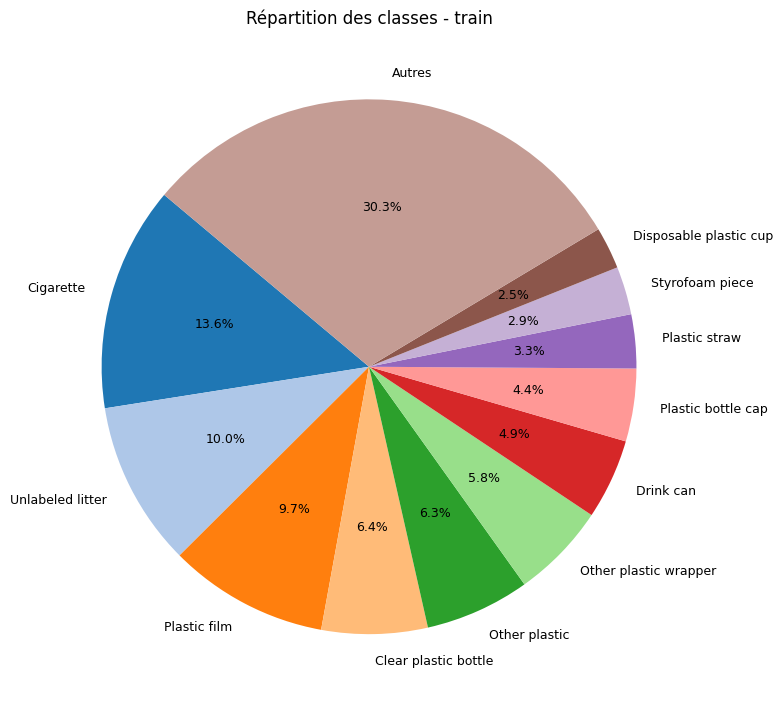

In [4]:
# Si aucune annotation trouvée
if len(sorted_names) == 0:
    print("Aucune annotation trouvée dans le fichier COCO.")
else:
    # Palette de couleurs automatique (en fonction du nombre de classes)
    n = len(sorted_names)
    cmap = cm.get_cmap('tab20' if n <= 20 else 'tab20b')
    COLORS = [cmap(i % cmap.N) for i in range(n)]

    # === 1. BAR CHART (Histogramme horizontal pour lisibilité) ===
    plt.figure(figsize=(12, max(6, 0.4 * n)))
    y_pos = list(range(len(sorted_names)))
    plt.barh(y_pos, sorted_values, color=COLORS)
    plt.yticks(y_pos, sorted_names)
    plt.gca().invert_yaxis()  # affiche la barre la plus grande en haut
    plt.xlabel("Nombre d'objets")
    plt.title("Nombre d'annotations par classe - train")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    bar_path = output_dir / "train_bar_chart.png"
    plt.savefig(str(bar_path), dpi=150)
    print(f"Histogramme sauvegardé : {bar_path}")
    plt.show()

    # === 2. PIE CHART (Camembert) ===
    plt.figure(figsize=(8, 8))
    # Pour lisibilité, si trop de classes, regrouper les petites en "Autres"
    if n > 12:
        # regrouper les classes après les 11 premières
        main_names = sorted_names[:11]
        main_vals  = sorted_values[:11]
        other_val = sum(sorted_values[11:])
        main_names.append("Autres")
        main_vals.append(other_val)
        pie_labels = main_names
        pie_values = main_vals
        cmap2 = cm.get_cmap('tab20')
        pie_colors = [cmap2(i % cmap2.N) for i in range(len(pie_labels))]
    else:
        pie_labels = sorted_names
        pie_values = sorted_values
        pie_colors = COLORS

    wedges, texts, autotexts = plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=140, colors=pie_colors)
    for t in texts:
        t.set_fontsize(9)
    for a in autotexts:
        a.set_fontsize(9)
    plt.title("Répartition des classes - train")
    plt.tight_layout()
    pie_path = output_dir / "train_pie_chart.png"
    plt.savefig(str(pie_path), dpi=150)
    print(f"Camembert sauvegardé : {pie_path}")
    plt.show()


In [5]:
# Préparer chemins pour Valid File
base_path = Path(base_path)
ann_path = base_path / ann__valid_filename
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Vérifications rapides
if not ann_path.exists():
    raise FileNotFoundError(f"Fichier d'annotations introuvable : {ann_path}")

In [6]:
# Charger COCO
coco = COCO(str(ann_path))

# Charger et trier les catégories par id
cats = sorted(coco.loadCats(coco.getCatIds()), key=lambda c: c['id'])
cat_id_to_name = {c['id']: c['name'] for c in cats}
names = [c['name'] for c in cats]

# Charger les annotations (objets)
ann_ids = coco.getAnnIds()
anns = coco.loadAnns(ann_ids)

# Compter les objets par classe (utiliser les noms)
class_counts = Counter()
for ann in anns:
    cat_id = ann['category_id']
    class_name = cat_id_to_name.get(cat_id, str(cat_id))
    class_counts[class_name] += 1

# Trier les classes par fréquence décroissante pour l'affichage
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
sorted_names = [name for name, _ in sorted_counts]
sorted_values = [count for _, count in sorted_counts]

# === Créer DataFrame pandas ===
df_valid = pd.DataFrame({
    'class_name': sorted_names,
    'annotations_count': sorted_values
})
df_valid['rare'] = df_valid['annotations_count'] < rare_threshold


loading annotations into memory...
Done (t=0.31s)
creating index...
index created!


In [7]:
df_valid

,class_name,annotations_count,rare
0,Cigarette,154,False
1,Unlabeled litter,113,False
2,Plastic film,89,False
3,Clear plastic bottle,58,False
4,Drink can,51,False
5,Plastic bottle cap,49,False
6,Other plastic,47,False
7,Broken glass,43,False
8,Other plastic wrapper,37,False
9,Glass bottle,34,False


/tmp/ipython-input-1559231102.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20' if n <= 20 else 'tab20b')


Histogramme sauvegardé : /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/outputs/valid_bar_chart.png


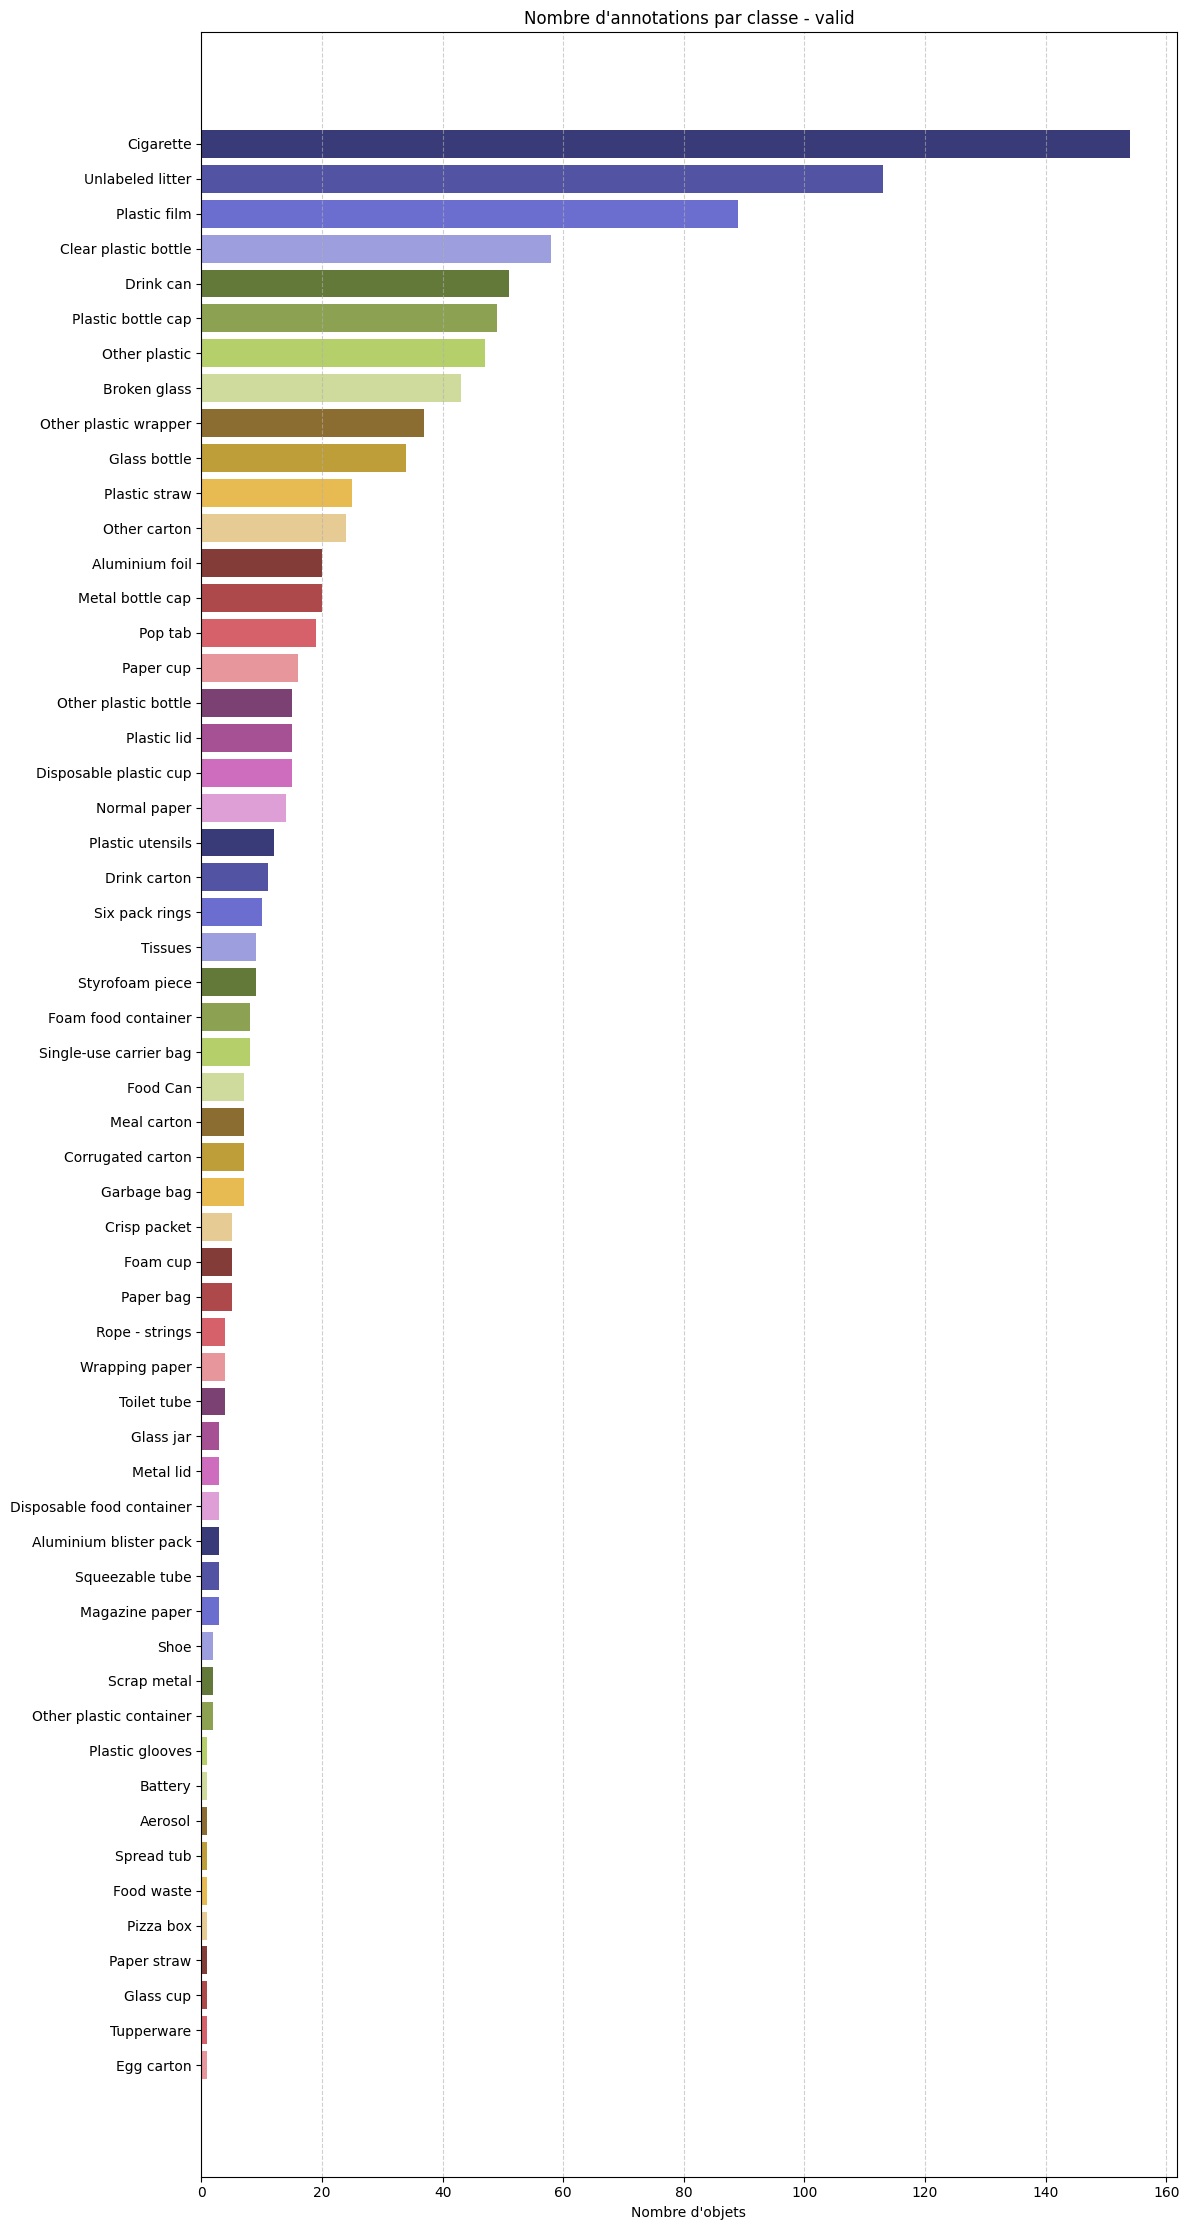

/tmp/ipython-input-1559231102.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('tab20')


Camembert sauvegardé : /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/outputs/valid_pie_chart.png


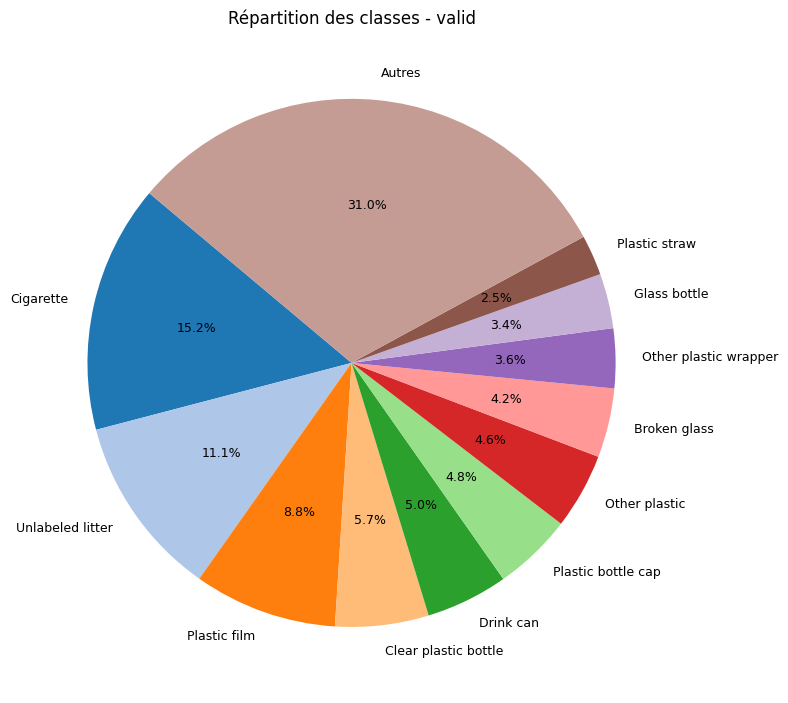

In [8]:
# Si aucune annotation trouvée
if len(sorted_names) == 0:
    print("Aucune annotation trouvée dans le fichier valid COCO.")
else:
    # Palette de couleurs automatique (en fonction du nombre de classes)
    n = len(sorted_names)
    cmap = cm.get_cmap('tab20' if n <= 20 else 'tab20b')
    COLORS = [cmap(i % cmap.N) for i in range(n)]

    # === 1. BAR CHART (Histogramme horizontal pour lisibilité) ===
    plt.figure(figsize=(12, max(6, 0.4 * n)))
    y_pos = list(range(len(sorted_names)))
    plt.barh(y_pos, sorted_values, color=COLORS)
    plt.yticks(y_pos, sorted_names)
    plt.gca().invert_yaxis()  # affiche la barre la plus grande en haut
    plt.xlabel("Nombre d'objets")
    plt.title("Nombre d'annotations par classe - valid")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    bar_path = output_dir / "valid_bar_chart.png"
    plt.savefig(str(bar_path), dpi=150)
    print(f"Histogramme sauvegardé : {bar_path}")
    plt.show()

    # === 2. PIE CHART (Camembert) ===
    plt.figure(figsize=(8, 8))
    # Pour lisibilité, si trop de classes, regrouper les petites en "Autres"
    if n > 12:
        # regrouper les classes après les 11 premières
        main_names = sorted_names[:11]
        main_vals  = sorted_values[:11]
        other_val = sum(sorted_values[11:])
        main_names.append("Autres")
        main_vals.append(other_val)
        pie_labels = main_names
        pie_values = main_vals
        cmap2 = cm.get_cmap('tab20')
        pie_colors = [cmap2(i % cmap2.N) for i in range(len(pie_labels))]
    else:
        pie_labels = sorted_names
        pie_values = sorted_values
        pie_colors = COLORS

    wedges, texts, autotexts = plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=140, colors=pie_colors)
    for t in texts:
        t.set_fontsize(9)
    for a in autotexts:
        a.set_fontsize(9)
    plt.title("Répartition des classes - valid")
    plt.tight_layout()
    pie_path = output_dir / "valid_pie_chart.png"
    plt.savefig(str(pie_path), dpi=150)
    print(f"Camembert sauvegardé : {pie_path}")
    plt.show()


In [9]:
# Préparer chemins pour Test File
base_path = Path(base_path)
ann_path = base_path / ann__test_filename
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Vérifications rapides
if not ann_path.exists():
    raise FileNotFoundError(f"Fichier d'annotations introuvable : {ann_path}")

In [10]:
# Charger COCO
coco = COCO(str(ann_path))

# Charger et trier les catégories par id
cats = sorted(coco.loadCats(coco.getCatIds()), key=lambda c: c['id'])
cat_id_to_name = {c['id']: c['name'] for c in cats}
names = [c['name'] for c in cats]

# Charger les annotations (objets)
ann_ids = coco.getAnnIds()
anns = coco.loadAnns(ann_ids)

# Compter les objets par classe (utiliser les noms)
class_counts = Counter()
for ann in anns:
    cat_id = ann['category_id']
    class_name = cat_id_to_name.get(cat_id, str(cat_id))
    class_counts[class_name] += 1

# Trier les classes par fréquence décroissante pour l'affichage
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
sorted_names = [name for name, _ in sorted_counts]
sorted_values = [count for _, count in sorted_counts]

# === Créer DataFrame pandas ===
df_test = pd.DataFrame({
    'class_name': sorted_names,
    'annotations_count': sorted_values
})
df_test['rare'] = df_test['annotations_count'] < rare_threshold


loading annotations into memory...
Done (t=0.34s)
creating index...
index created!


In [11]:
df_test

,class_name,annotations_count,rare
0,Unlabeled litter,81,False
1,Cigarette,69,False
2,Broken glass,55,False
3,Plastic film,47,False
4,Other plastic wrapper,32,False
5,Plastic straw,27,True
6,Other plastic,26,True
7,Drink can,25,True
8,Clear plastic bottle,21,True
9,Plastic bottle cap,19,True


/tmp/ipython-input-3528200775.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20' if n <= 20 else 'tab20b')


Histogramme sauvegardé : /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/outputs/test_bar_chart.png


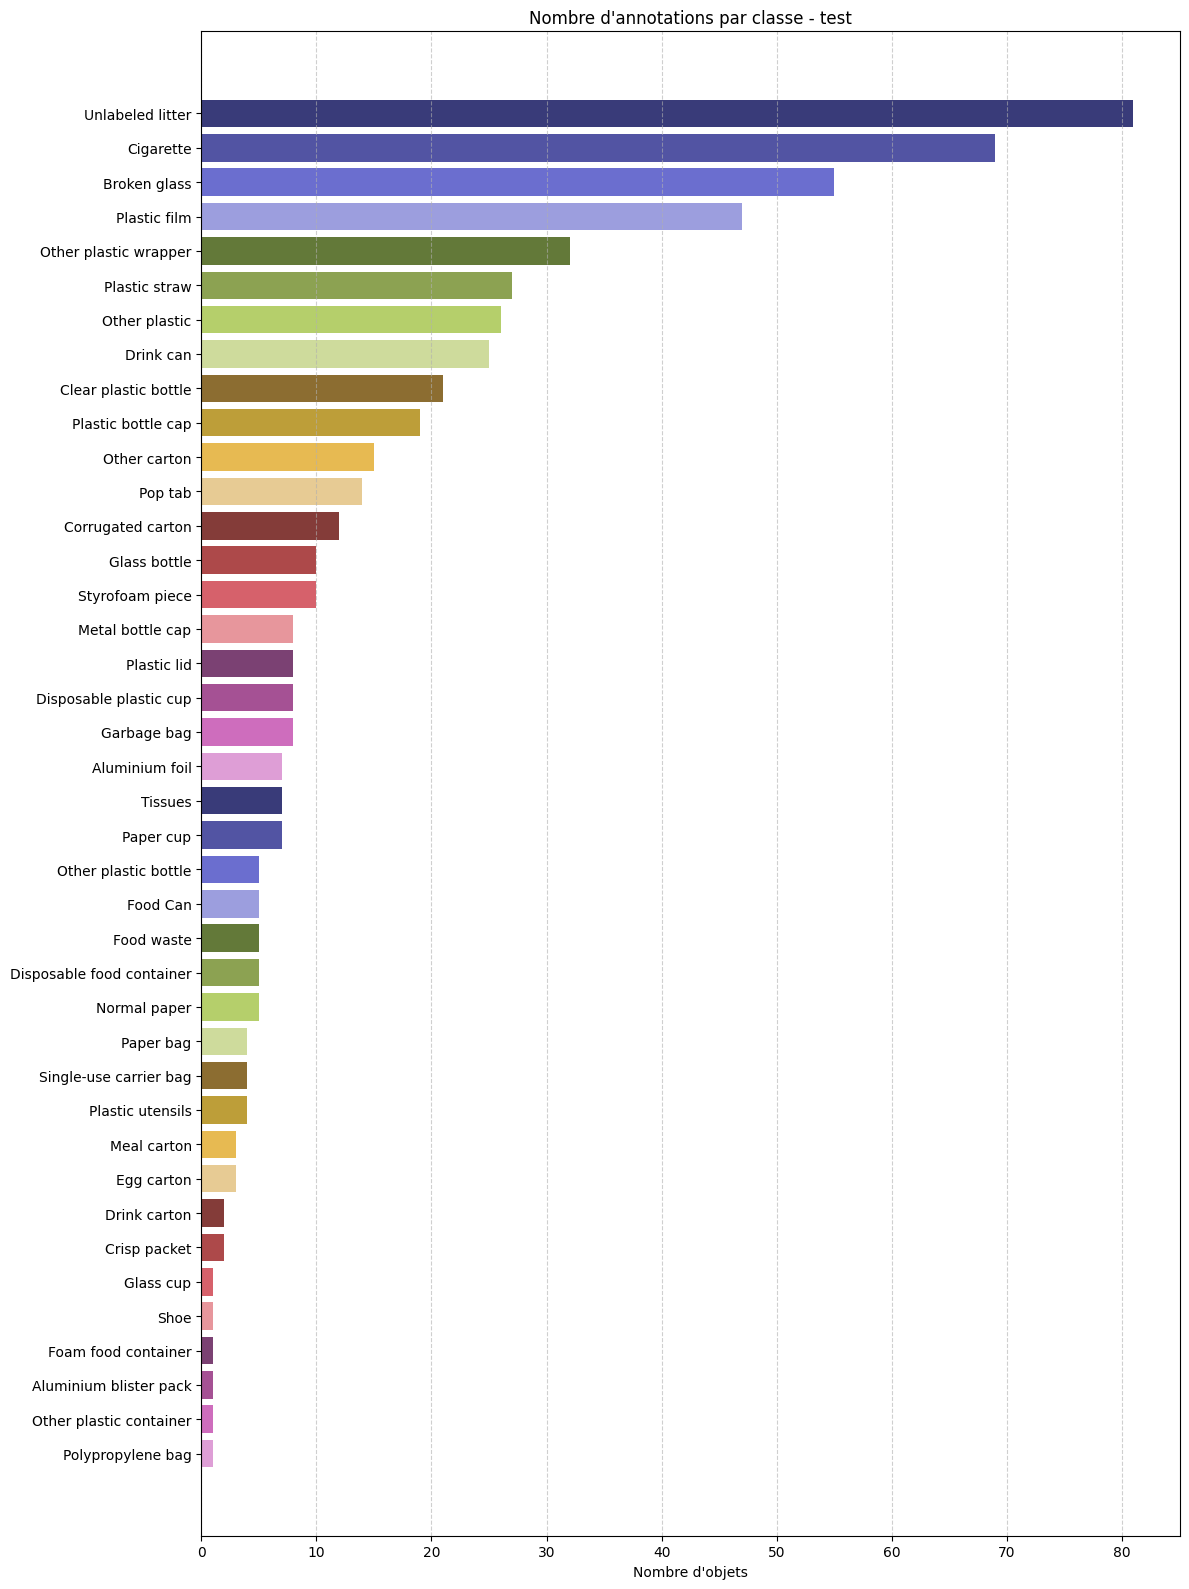

/tmp/ipython-input-3528200775.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap2 = cm.get_cmap('tab20')


Camembert sauvegardé : /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/outputs/test_pie_chart.png


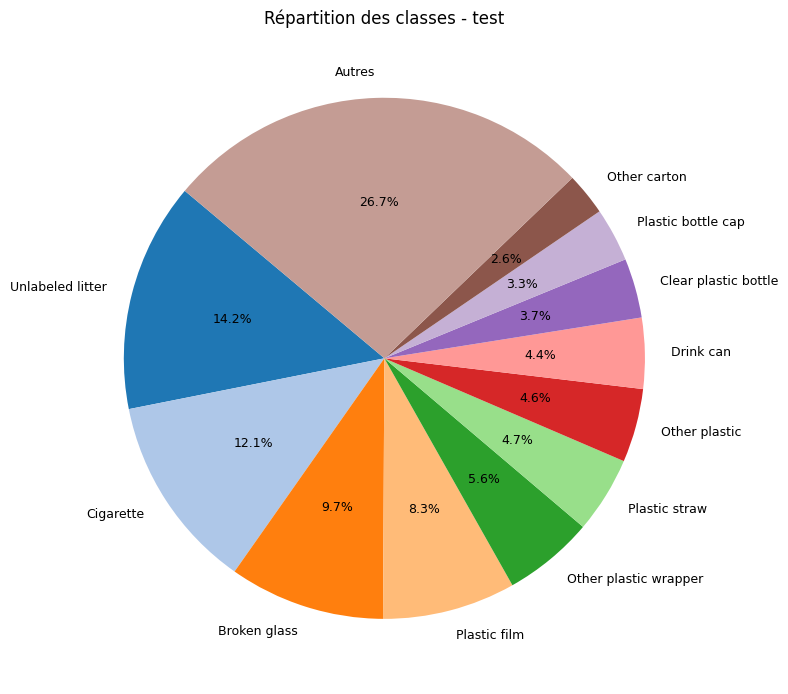

In [12]:
# Si aucune annotation trouvée
if len(sorted_names) == 0:
    print("Aucune annotation trouvée dans le fichier  de Test COCO.")
else:
    # Palette de couleurs automatique (en fonction du nombre de classes)
    n = len(sorted_names)
    cmap = cm.get_cmap('tab20' if n <= 20 else 'tab20b')
    COLORS = [cmap(i % cmap.N) for i in range(n)]

    # === 1. BAR CHART (Histogramme horizontal pour lisibilité) ===
    plt.figure(figsize=(12, max(6, 0.4 * n)))
    y_pos = list(range(len(sorted_names)))
    plt.barh(y_pos, sorted_values, color=COLORS)
    plt.yticks(y_pos, sorted_names)
    plt.gca().invert_yaxis()  # affiche la barre la plus grande en haut
    plt.xlabel("Nombre d'objets")
    plt.title("Nombre d'annotations par classe - test")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    bar_path = output_dir / "test_bar_chart.png"
    plt.savefig(str(bar_path), dpi=150)
    print(f"Histogramme sauvegardé : {bar_path}")
    plt.show()

    # === 2. PIE CHART (Camembert) ===
    plt.figure(figsize=(8, 8))
    # Pour lisibilité, si trop de classes, regrouper les petites en "Autres"
    if n > 12:
        # regrouper les classes après les 11 premières
        main_names = sorted_names[:11]
        main_vals  = sorted_values[:11]
        other_val = sum(sorted_values[11:])
        main_names.append("Autres")
        main_vals.append(other_val)
        pie_labels = main_names
        pie_values = main_vals
        cmap2 = cm.get_cmap('tab20')
        pie_colors = [cmap2(i % cmap2.N) for i in range(len(pie_labels))]
    else:
        pie_labels = sorted_names
        pie_values = sorted_values
        pie_colors = COLORS

    wedges, texts, autotexts = plt.pie(pie_values, labels=pie_labels, autopct='%1.1f%%', startangle=140, colors=pie_colors)
    for t in texts:
        t.set_fontsize(9)
    for a in autotexts:
        a.set_fontsize(9)
    plt.title("Répartition des classes - test")
    plt.tight_layout()
    pie_path = output_dir / "test_pie_chart.png"
    plt.savefig(str(pie_path), dpi=150)
    print(f"Camembert sauvegardé : {pie_path}")
    plt.show()


In [13]:
# Fusion df_train et df_test sur class_name
merged_1 = pd.merge(df_train, df_test, on='class_name', how='outer', suffixes=('_train', '_test'))

# Puis fusion avec df_valid (on ajoute un nouveau suffixe)
final_merged = pd.merge(merged_1, df_valid, on='class_name', how='outer')

# Optionnel : renommer les colonnes venant de df_valid si nécessaire
final_merged.rename(columns={
    'annotations_count': 'annotations_count_valid',
    'rare': 'rare_valid'
}, inplace=True)


In [14]:
final_merged

,class_name,annotations_count_train,rare_train,annotations_count_test,rare_test,annotations_count_valid,rare_valid
0,Aerosol,27,True,NaN,NaN,1.0,True
1,Aluminium blister pack,6,True,1.0,True,3.0,True
2,Aluminium foil,111,False,7.0,True,20.0,True
3,Battery,3,True,NaN,NaN,1.0,True
4,Broken glass,117,False,55.0,False,43.0,False
5,Carded blister pack,3,True,NaN,NaN,NaN,NaN
6,Cigarette,1286,False,69.0,False,154.0,False
7,Clear plastic bottle,606,False,21.0,True,58.0,False
8,Corrugated carton,138,False,12.0,True,7.0,True
9,Crisp packet,96,False,2.0,True,5.0,True


In [15]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.2 MB/s eta 0:00:00


In [16]:
#yolo train model=yolov8s.pt data=path/to/data.yaml epochs=50 imgsz=640 batch=16 name=taco_run


In [17]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')
results = model.train(
    data='/content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Taco_Dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='taco_run'
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.218 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Taco_Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=


image 1/1 /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Trash_bottle.jpeg: 448x640 (no detections), 13.6ms
Speed: 2.5ms preprocess, 13.6ms inference, 0.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict2


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
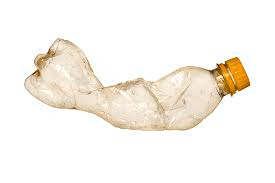

In [20]:
from ultralytics import YOLO

# Charger le modèle entraîné
model = YOLO('runs/detect/taco_run/weights/best.pt')

# Détecter sur une image
results = model.predict(source='/content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Trash_bottle.jpeg', save=True)

# Afficher les résultats
results[0].plot()  # retourne une image avec les boîtes et labels



image 1/1 /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Trash_bottle_2.jpeg: 640x512 2 Garbage bags, 1 Plastic bottle cap, 29.7ms
Speed: 5.0ms preprocess, 29.7ms inference, 3.9ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/runs/detect/predict8


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 50,  50,  50],
        [ 49,  49,  49],
        [ 58,  58,  58],
        ...,
        [ 50,  50,  50],
        [ 50,  50,  50],
        [ 50,  50,  50]],

       [[ 50,  50,  50],
        [ 50,  50,  50],
        [ 50,  50,  50],
        ...,
        [ 50,  50,  50],
        [ 50,  50,  50],
        [ 50,  50,  50]],

       [[ 50,  50,  50],
        [ 50,  50,  50],
        [ 50,  50,  50],
        ...,
        [ 50,  50,  50],
        [ 50,  50,  50],
        [ 50,  50,  50]]], dtype=uint8)
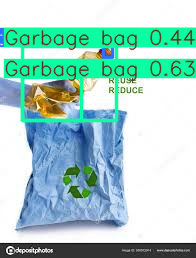

In [29]:
from ultralytics import YOLO

# Charger le modèle entraîné
model = YOLO('runs/detect/taco_run/weights/best.pt')

# Détecter sur une image
results = model.predict(source='/content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Trash_bottle_2.jpeg', save=True)

# Afficher les résultats
results[0].plot()  # retourne une image avec les boîtes et labels


In [31]:
from ultralytics import YOLO

model = YOLO('runs/detect/taco_run/weights/best.pt')

# Évaluer sur le dataset de validation/test
results = model.val(data='/content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Taco_Dataset/data.yaml')

# Pour voir le résumé complet
results.summary()



Ultralytics 8.3.218 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,148,417 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.5 ms, read: 37.1±21.6 MB/s, size: 100.6 KB)
val: Scanning /content/drive/MyDrive/MasterAI-S3/Computer Vision/Projet_CV/Taco_Dataset/valid/labels.cache... 299 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 299/299 389.0Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.1it/s 6.1s
                   all        299       1014      0.505      0.165      0.181      0.147
               Aerosol          1          1          0          0     0.0276     0.0276
Aluminium blister pack          3          3          1          0      0.178       0.16
        Aluminium foil         11         20      0.705      0.359      0.384      0.352
               Battery          1          1          1          0          0   

[{'Class': 'Aerosol',
  'Images': np.int64(1),
  'Instances': np.int64(1),
  'Box-P': np.float64(0.0),
  'Box-R': np.float64(0.0),
  'Box-F1': np.float64(0.0),
  'mAP50': np.float64(0.02764),
  'mAP50-95': np.float64(0.02764)},
 {'Class': 'Aluminium blister pack',
  'Images': np.int64(3),
  'Instances': np.int64(3),
  'Box-P': np.float64(1.0),
  'Box-R': np.float64(0.0),
  'Box-F1': np.float64(0.0),
  'mAP50': np.float64(0.178),
  'mAP50-95': np.float64(0.1602)},
 {'Class': 'Aluminium foil',
  'Images': np.int64(11),
  'Instances': np.int64(20),
  'Box-P': np.float64(0.70509),
  'Box-R': np.float64(0.35933),
  'Box-F1': np.float64(0.47606),
  'mAP50': np.float64(0.38392),
  'mAP50-95': np.float64(0.35198)},
 {'Class': 'Battery',
  'Images': np.int64(1),
  'Instances': np.int64(1),
  'Box-P': np.float64(1.0),
  'Box-R': np.float64(0.0),
  'Box-F1': np.float64(0.0),
  'mAP50': np.float64(0.0),
  'mAP50-95': np.float64(0.0)},
 {'Class': 'Broken glass',
  'Images': np.int64(4),
  'Instance